# Week-3 Day-1 (First SQL Task)
---

- Note: I know that the instructions say to have an md file but I am going to use an ipynb, hopefully that is not an issue, ipynbs are much easier to navigate

## Part 1: Introduction to Databases

I will answer these with just pre-existing knowledge instead of wasting time googling every single formal definition

- **What is a Database?**
  - A database is more or less a DataStructure that we use to store data, how the data structure is organized depends on the type of database, generally speaking, we have two types of databases
    - Relational Databases (SQL)
    - Non-Relational Databases (NoSQL, eg: firebase being a document store or convex or neo4j beings a graph db)
  - Although it is worth noting that now we do have diff types of databases too, like in RAG we have vector databases like pinecone, chromadb, or qdrant, and also pgvector extension inside postgres. And we also have time series databases as well, although they maybe simply classified as NoSQL at times.
- **Database vs CSV vs Excel**
  - I assume the question is specifically asking for a comparison between RDBMS and CSV and Excel, not NoSQL DBs since that wouldn't make sense
  - Relational Databases: Data is stored in tables (rows and columns). The rows are also called records and columns are aka attributes, although in data science and ML we usually refer to columns as Features. Once your data is stored in an RDBMS, you have the power of using SQL to query the db and manipulate the existing data, that is the main benefit of storing data in an RDBMS instead of an excel file or csv
  - CSV is also more or less a table with rows and columns but raw CSV files are simply comma separated values. The top row is of course the column header and the rest are normal rows (records). In week-2, we have been working with almost exclusively CSV data. The issue with CSV is that we can't directly use SQL to query it or manipulate the data. The approaches we have with CSV data are: 1. use pandas to turn it into a dataframe and perform your manipulations. 2. use google sheets or excel and open the CSV in that and then use the built-in tooling and formulas to analyze, query, and manipulate data. You will need some extension or add on to use SQL on CSVs
  - Excel files are like 5% easier to work with as compared to CSVs but they are essentially the same thing, they have the xlsx extension and you can easily work with them in both pandas and in excel or google sheets. But again, you can't just write SQL queries that directly work on an excel file, you have to convert the xlsx file and store it in a sql db or use someother third party tool or add on
- **Relational Databases**
  - There are two main types of DBs as I already said in the answer of question 1, relational and non-relational. Relational databases use SQL, whatever flavor of SQL it may be (sqlite or mysql or postgres or oracle or whatever else). A Relational database is a type of db that you can query with SQL and data is stored in the form of tables in it (simple 2D matrix with rows and columns). Some more DB terminology would be that tables are usually called Relations and rows are usually called tuples. If you want to copy the book-version of the definition then relational databases are databases that adhere to relational algebra (whatever that means :)
- **Tables, Rows & Columns**
  - I already covered this in the previous question but lets go again just for the sake of completion. All 3 of these are basically constructs in a relational database. lets go one by one:
    - Table: 2D matrix consisting of rows and columns stored in a RDBMS. We can query it using SQL. AKA relations
    - Column: The vertical property that defines the data, one table can have several columns, and columns are also called attributes or features
    - Row: The horizontal record, it basically represent one record of data. This is also called sample in data science I think, and normally called tuple in databases. If you have 200 rows, you basically have 200 samples.
- **Primary Key**
  - Each record of data needs some sort of unique identifier to distinguish it from the rest. We usually have a simple 0 to infinite index as the first column which serves as the primary key, although many a times you will have a table where a column is unique for each row and you can just use that as the primary key. An example would be the player_id column in the afl dataset we worked with in week-2. It is the minimum set of attributes (columns) used to uniquely identify each record. One thing worth noting is that the primary key must be unique and not-nul (pk constraint)
- **Foreign Key**
  - This is a column in a table that refers to the primary key of another table. This is basically what makes RDBMS "relational". We make relations between tables using foreign keys. And joins on multiple tables are also performed using foreign keys. An example is how we used player_id in the info_df and seasonal_df to merge both of them. The main constraint of FK is referential constraint (a value either matches the existing primary key or is null)
- **Relationships**
  - When we build relationships between tables using foreign keys, we can endup forming several types of relationships between tables, here are the main relationships:
    - One to One: the foreign key matches exactly one PK, a simple example would be an employee table and a supervisor table in a company where an employee must only have one supervisor and not more or less. So, one employee will be supervised by one supervisor and one supervisor will supervise only one employee
    - One to Many: A primary key can match to multiple foreign keys of the other relation. A simple example would be a relationship between an employee table and a tasks table where one employee can be assigned multiple tasks but one task can only be assigned to one employee only.
    - Many to Many: Consider the same employee and tasks example but now, consider a company where one single task can be assigned to multiple employees: then one employee can have multiple tasks assigned to him and one task can also be assigned to multiple employees, hence its many to many

---

## Part 2: Postgres and PgAdmin Setup (go to readme.md in this same directory Week-3/Day-1/readme.md)

The instructions say to write about the setup in readme.md so I will write it there

I will paste the screenshots here still:

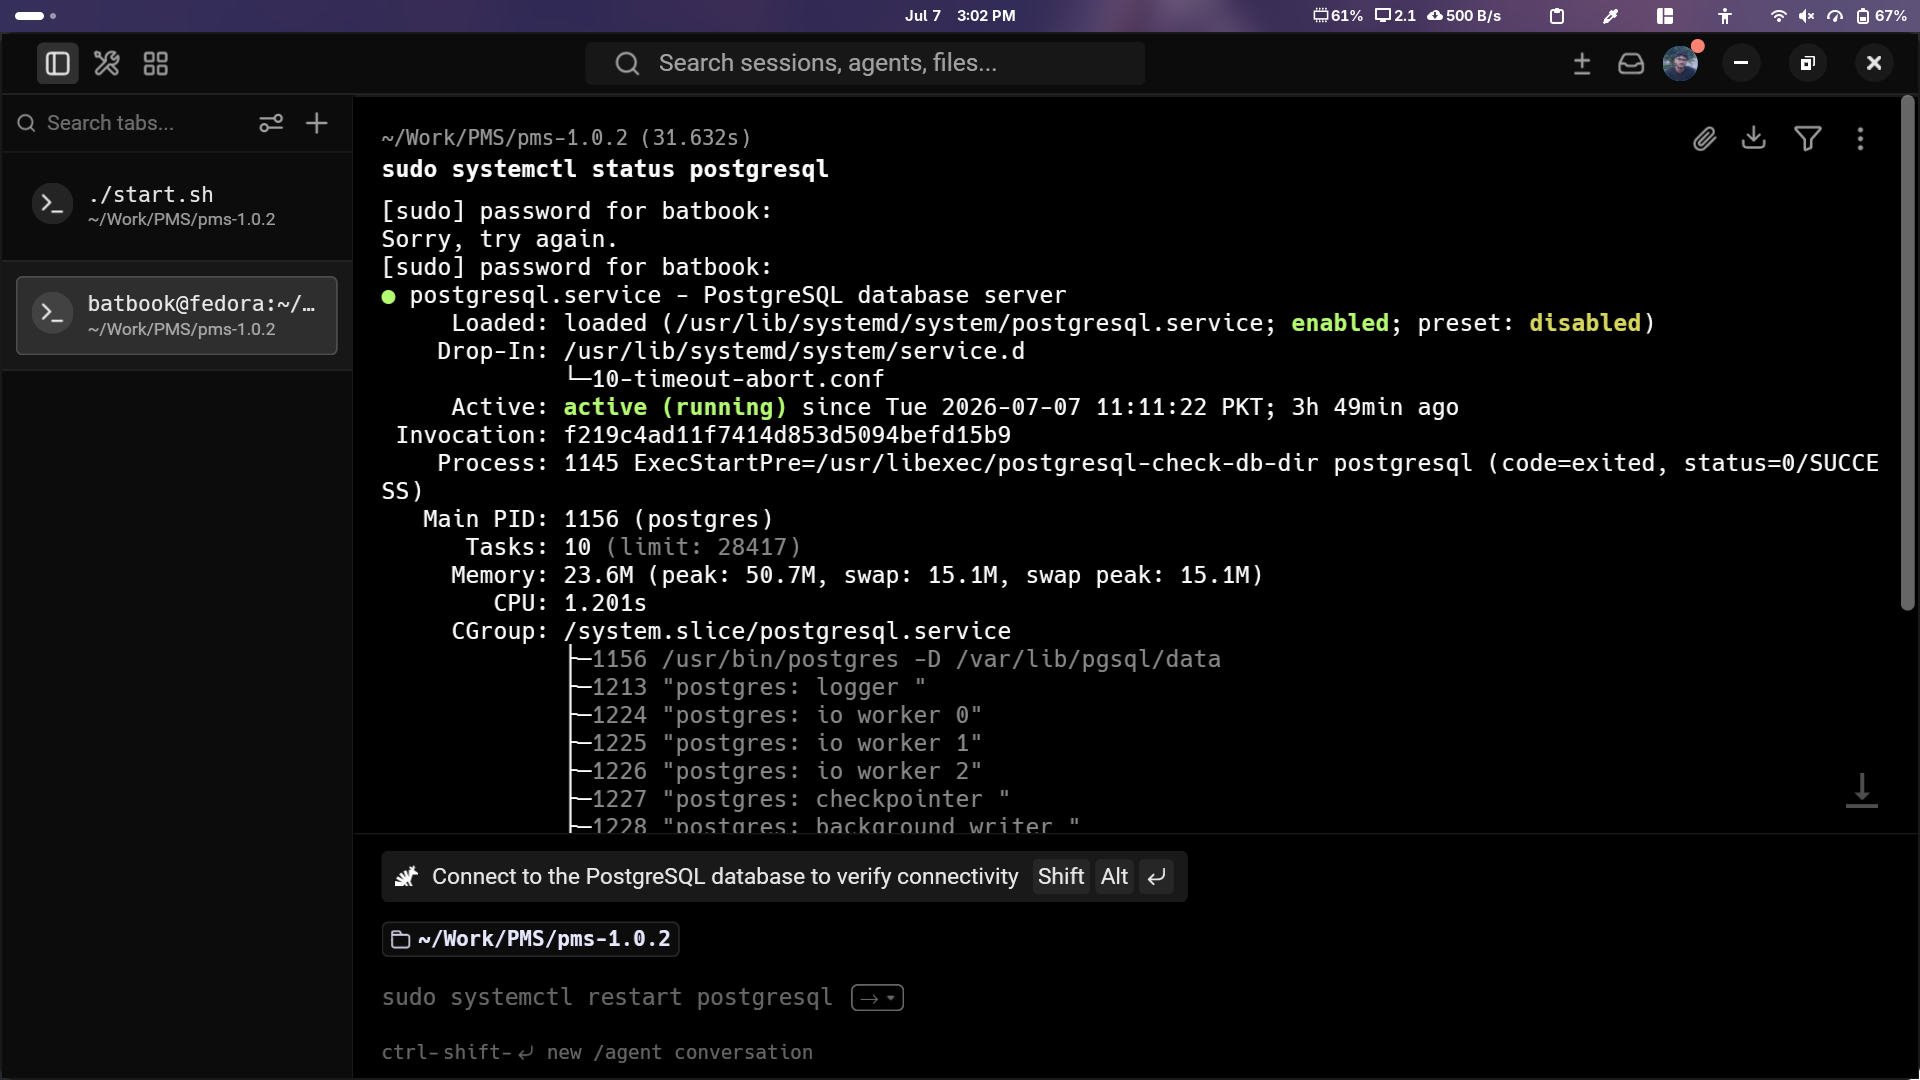

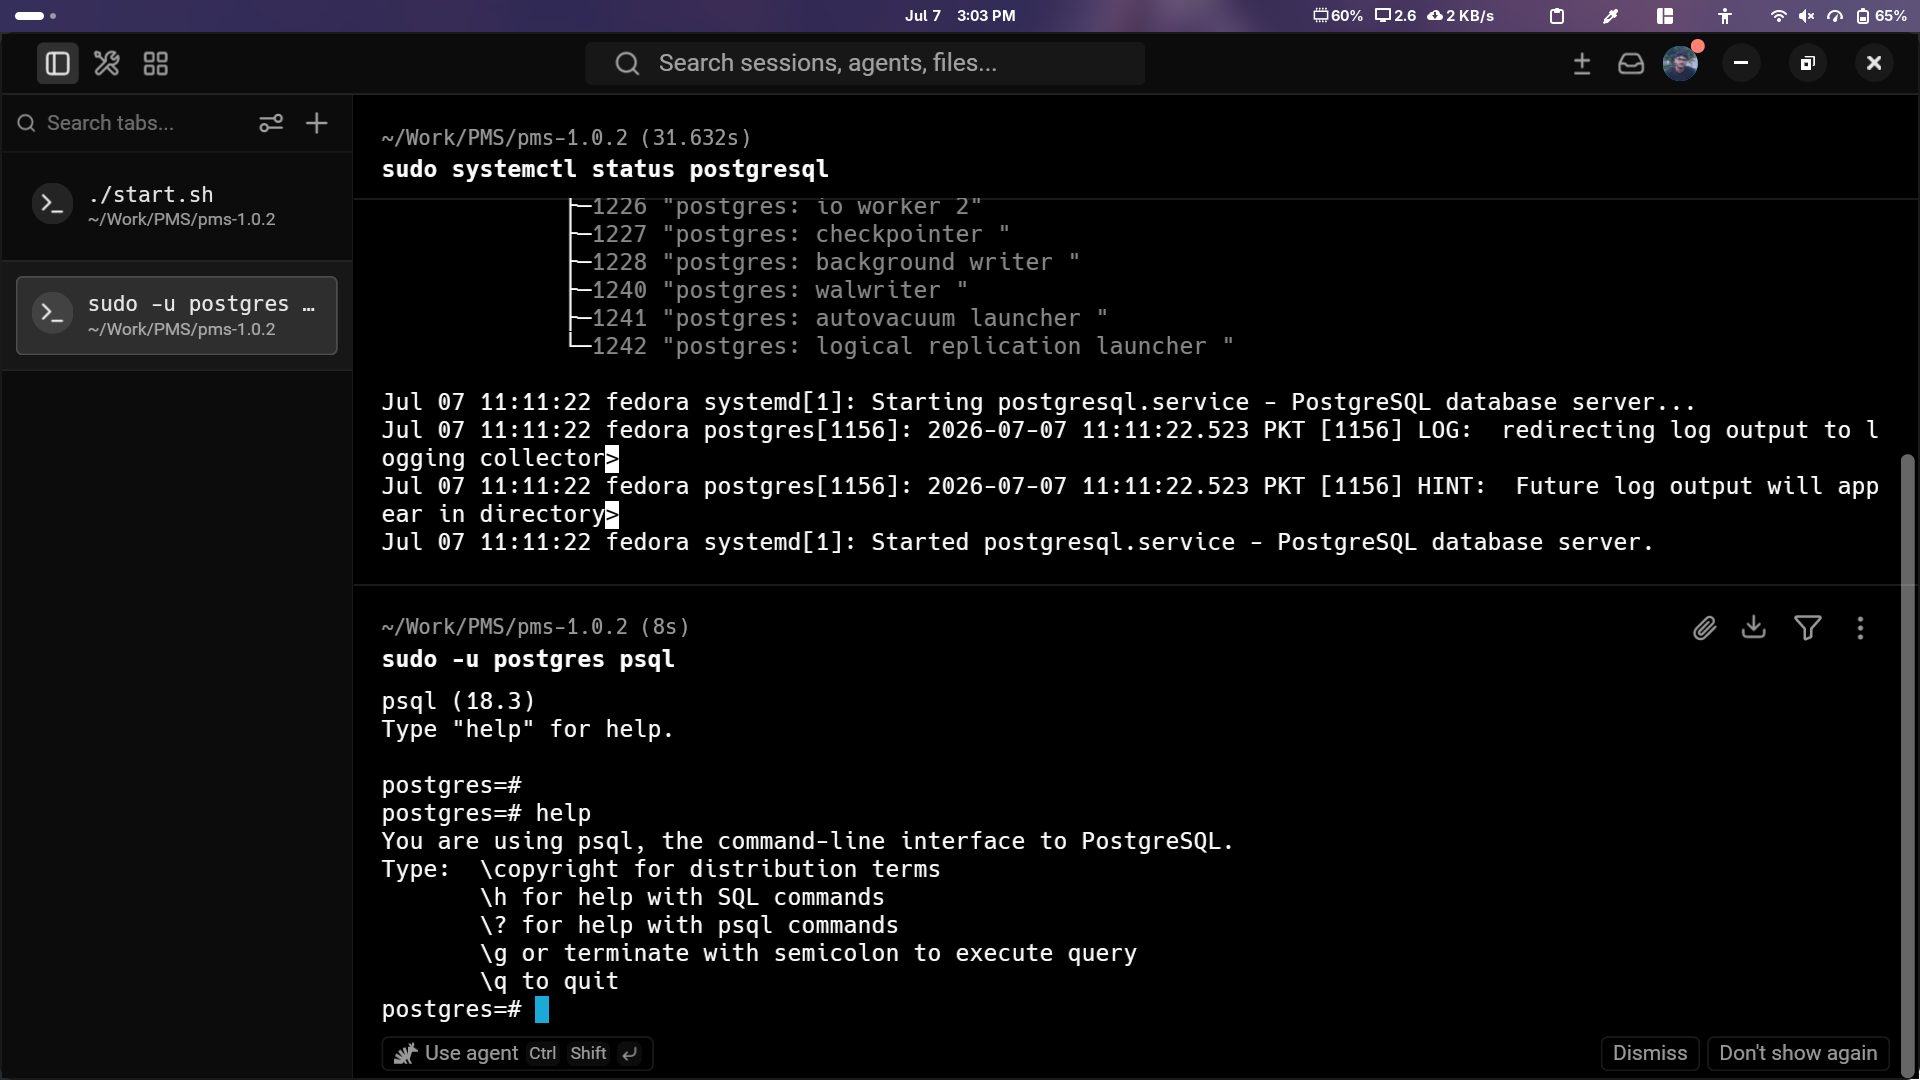

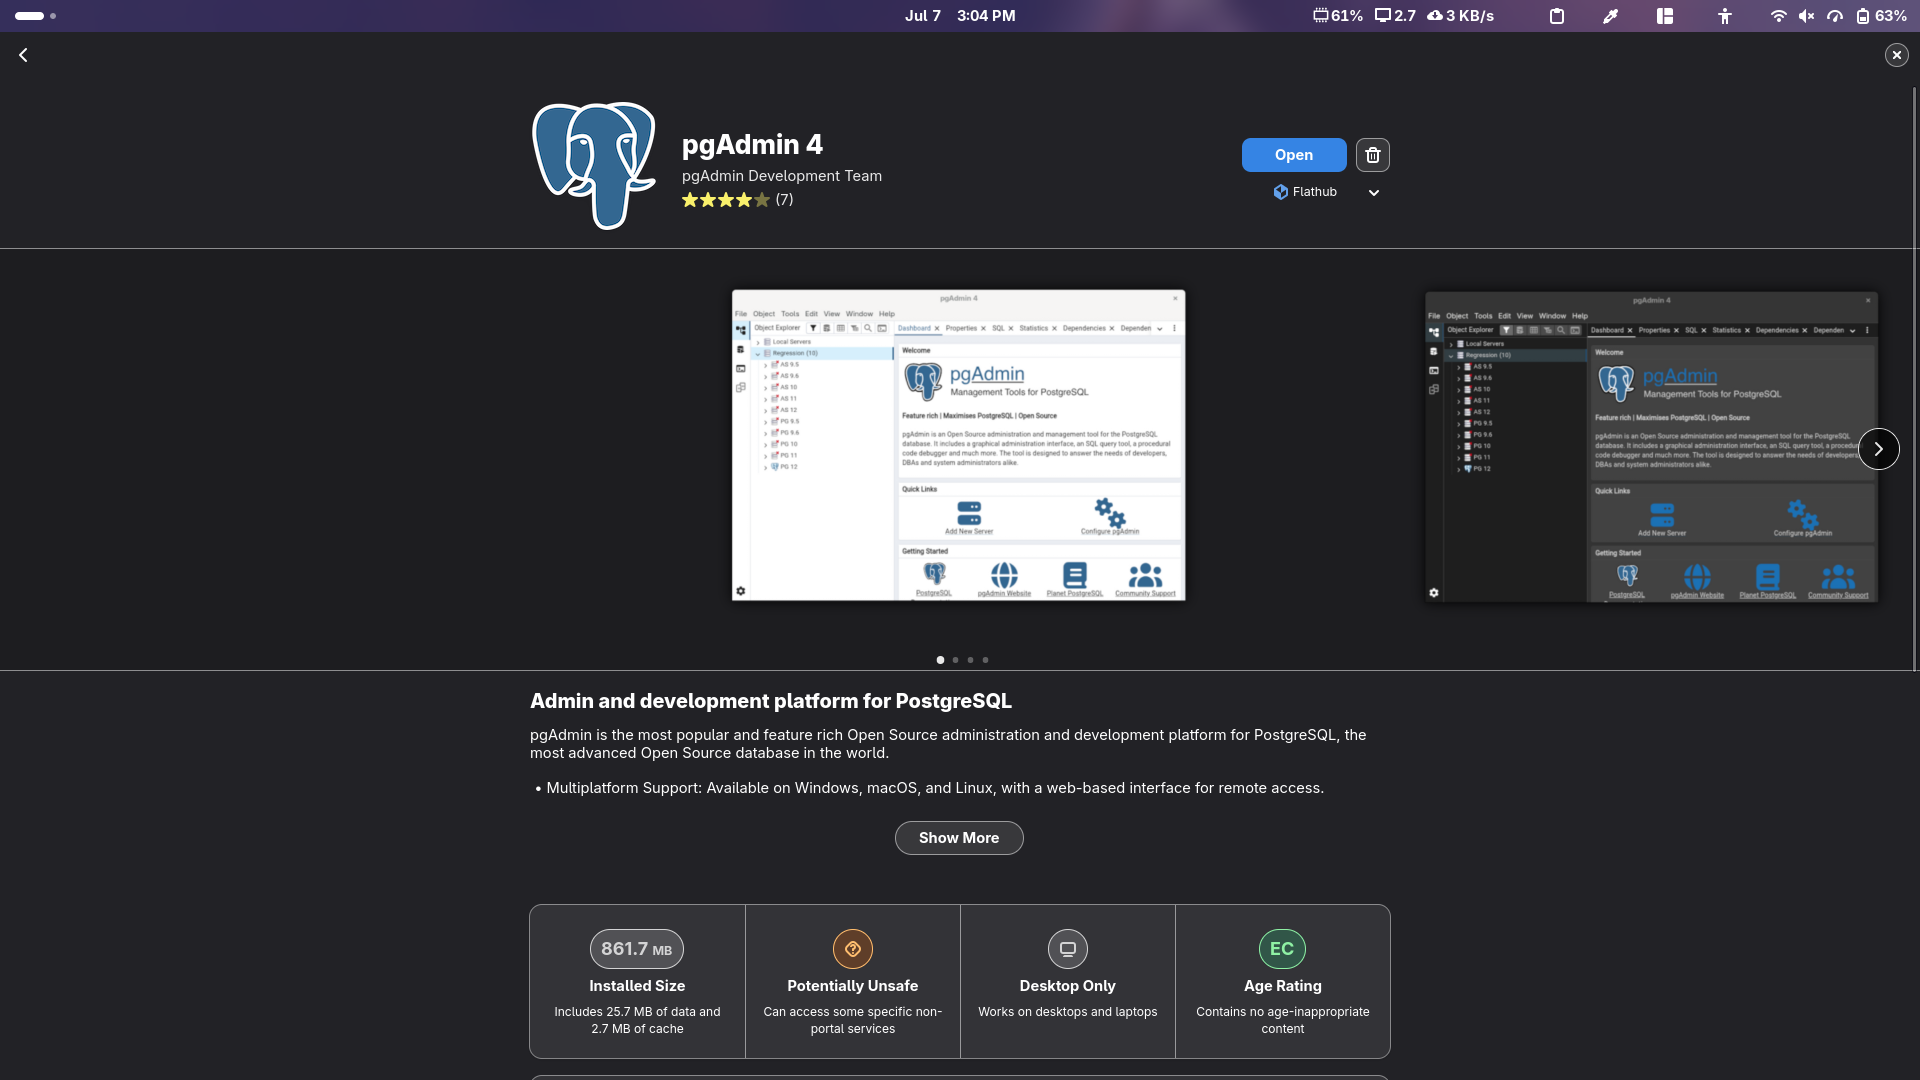

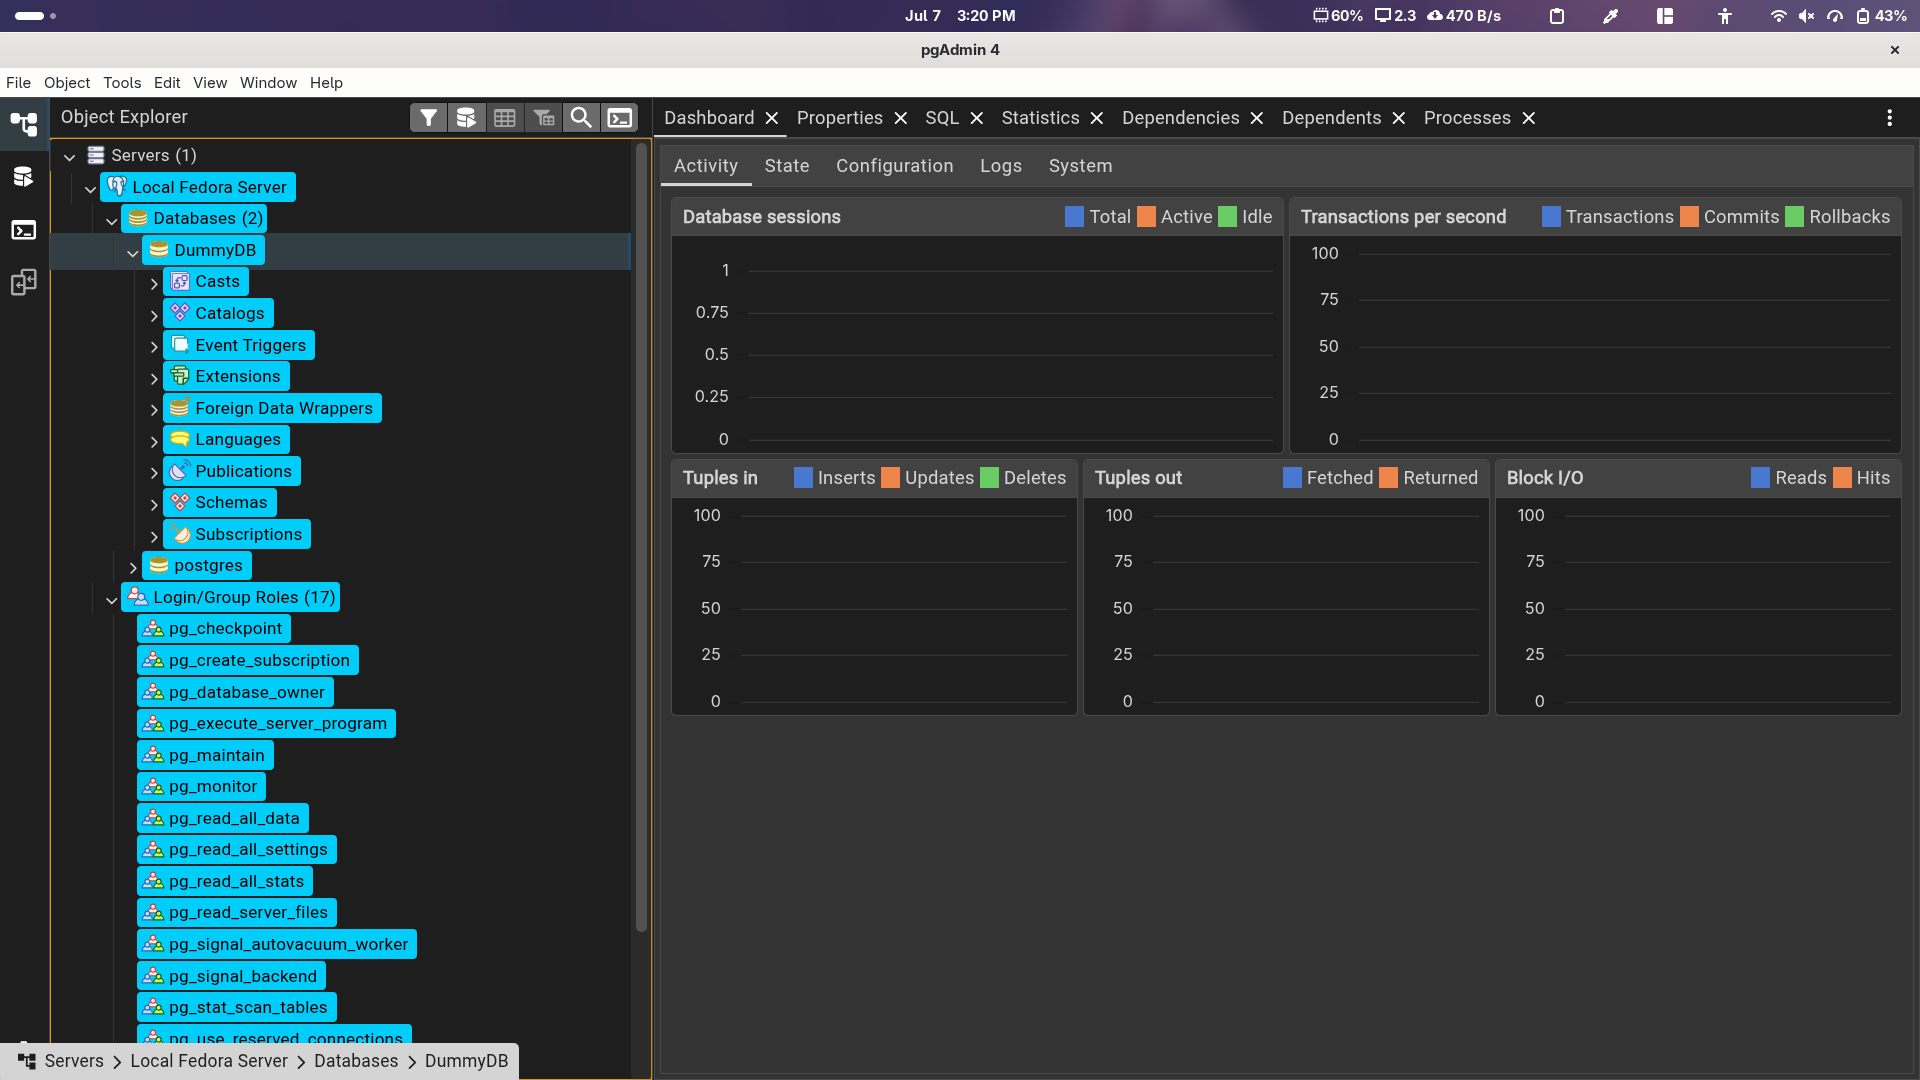





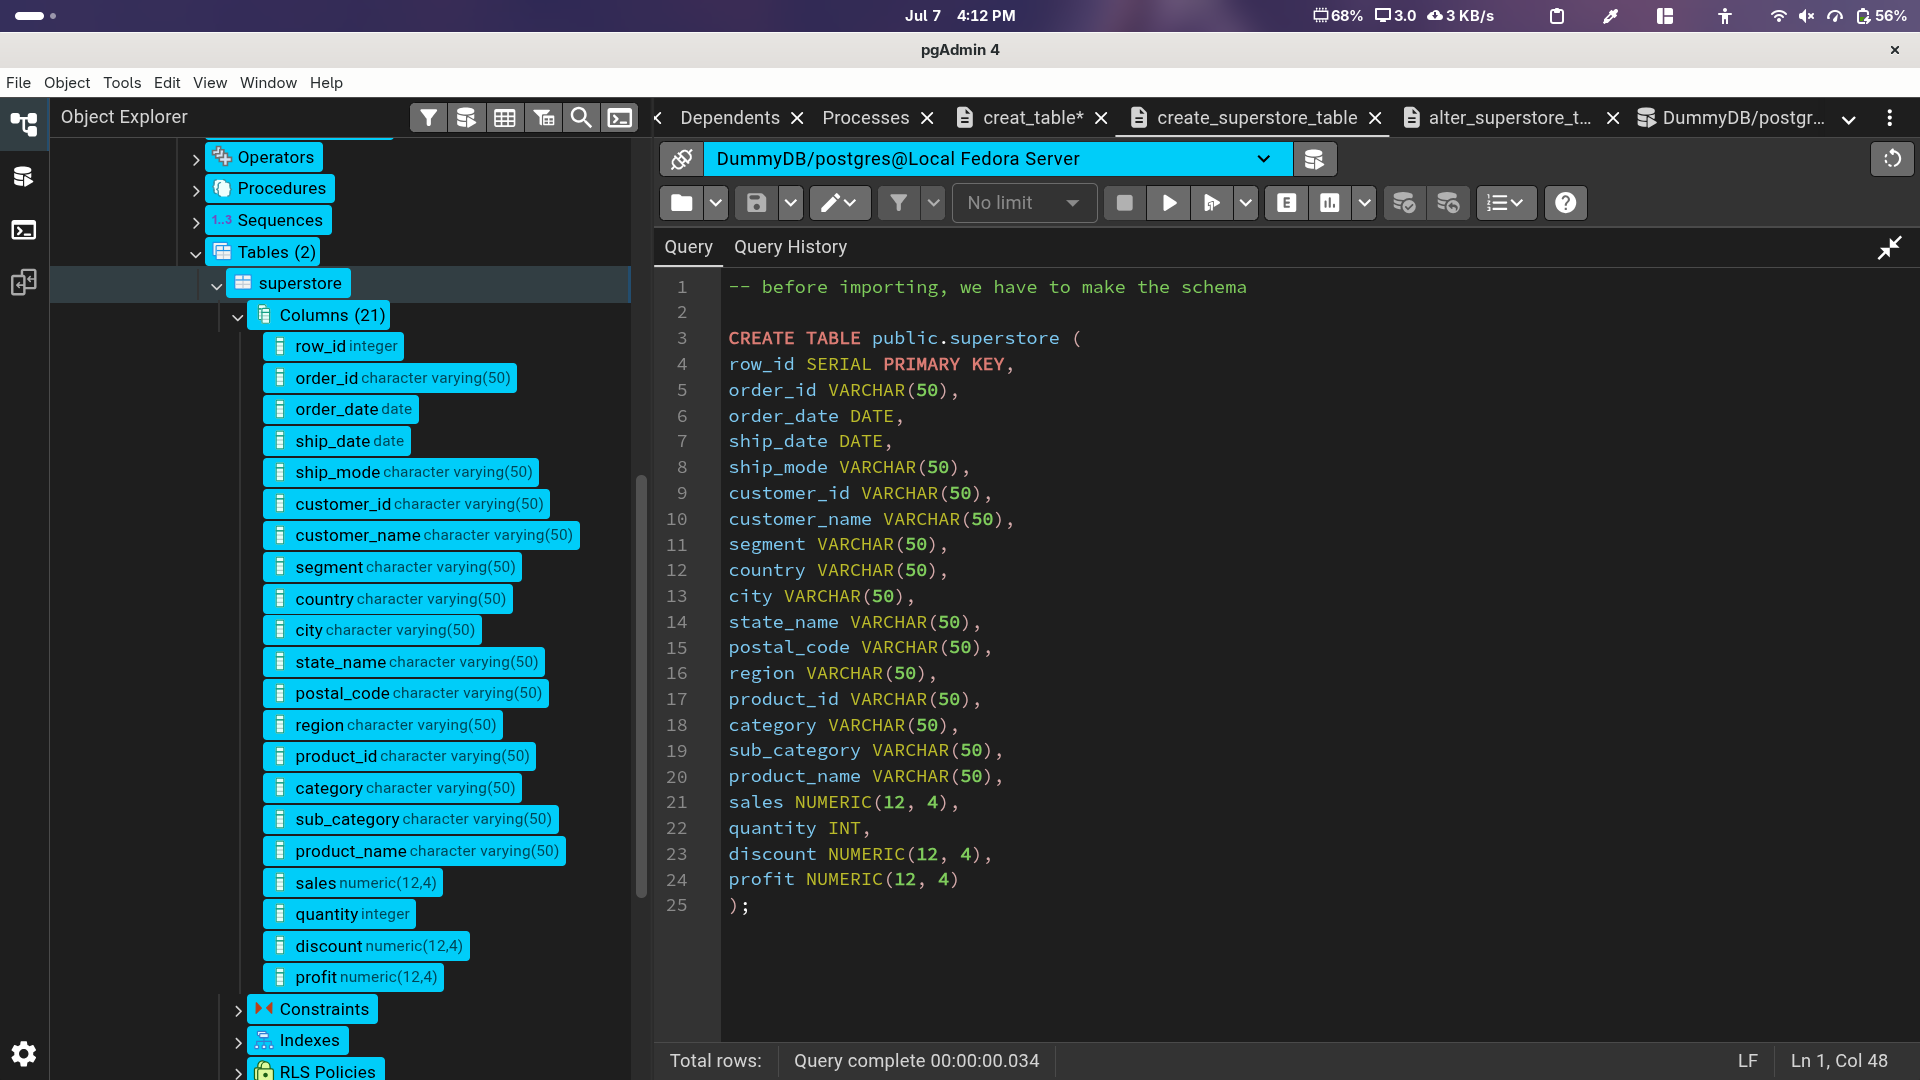

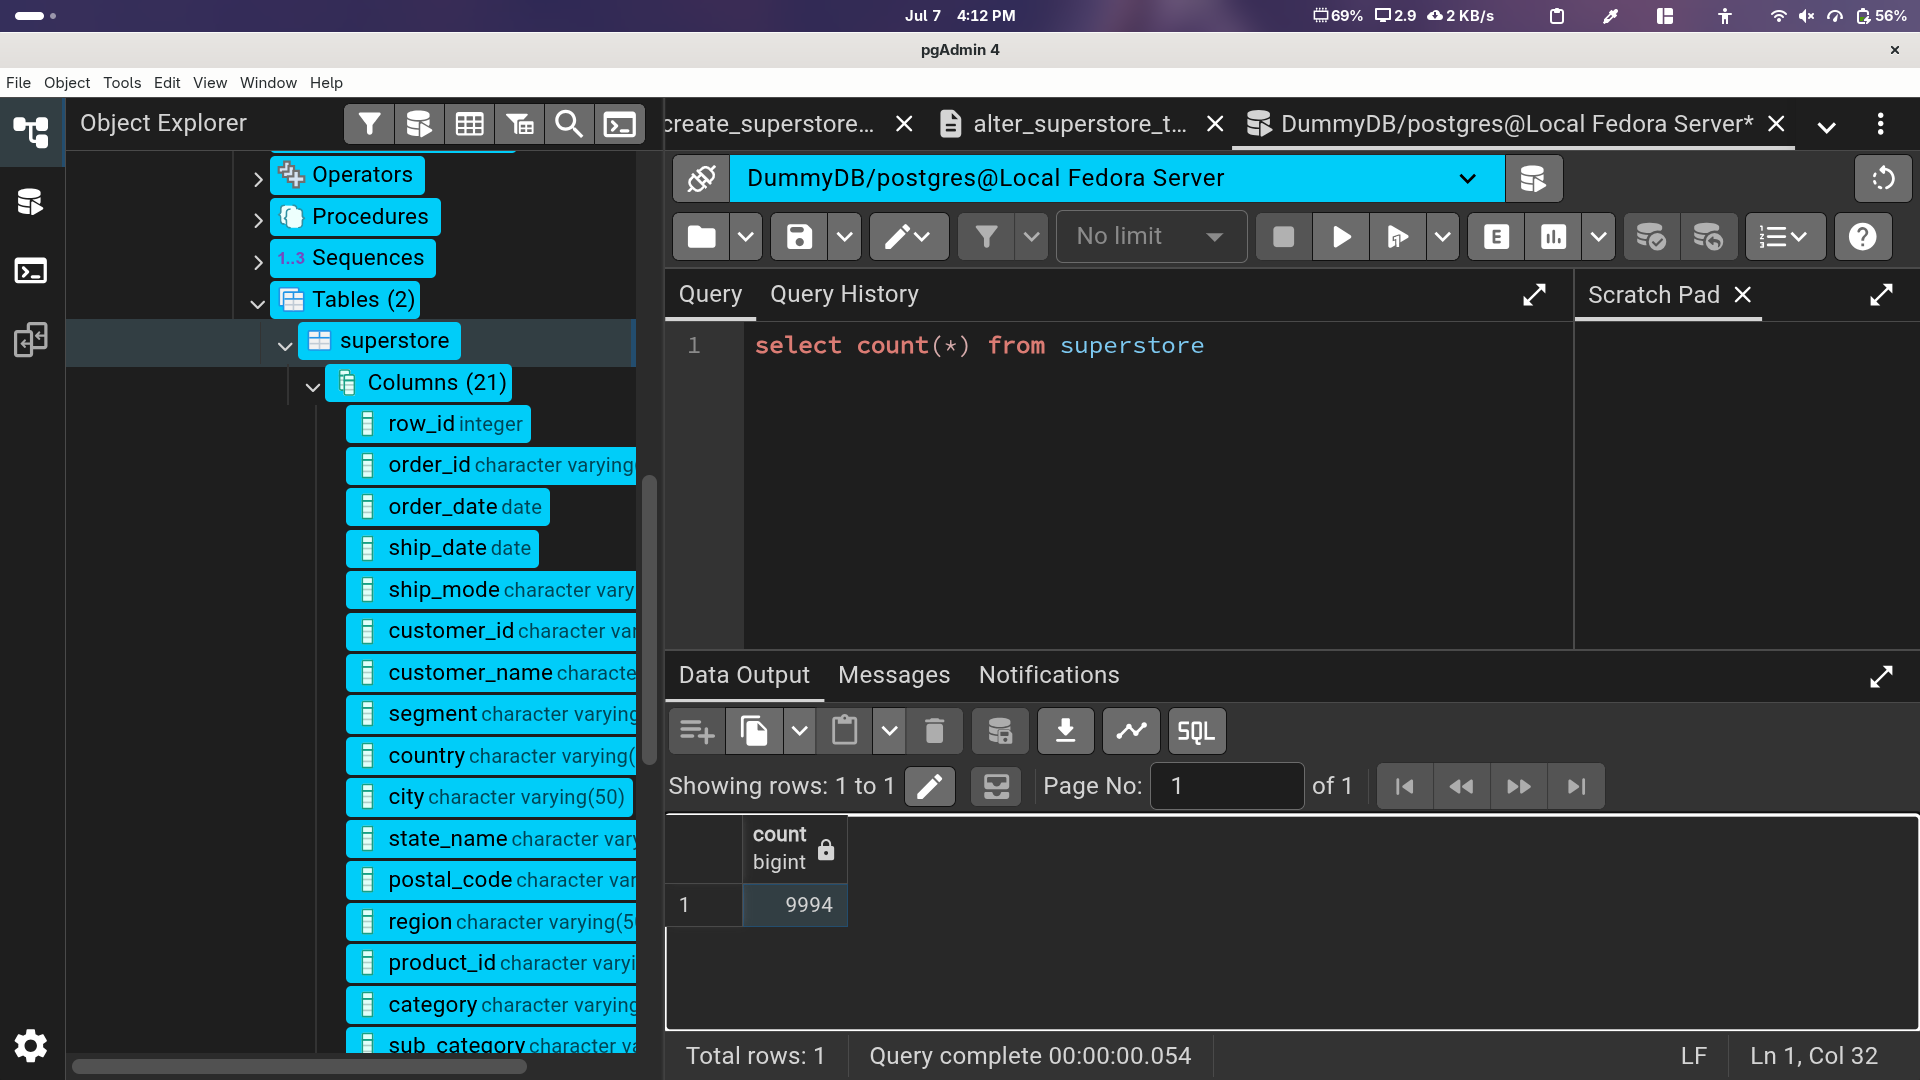

---

## Part 3: SQL Basics

I will write a simple explanation of each of these and provide some screenshots of the practice I did afterwards

- **SELECT**
  - Use this for printing out specific featutres or metrics. You just write SELECT and then column names after this. One thing I read that was cool is that if you do SELECT * then that will force a Disk Read of the entire table, it would bypass and make indexes useless as well. If you use column names insteaed of * then you will get the benefits of indexing
- **DISTINCT**
  - Used to remove duplicates from result, placed right after the SELECT clause, if you have multiple null values, DISTINCT will treat these as duplicates and give you only one null value row.
- **WHERE**
  - Where clause is used to put conditions on the print output, it is essentially used for filtering. It uses short circuit evaluation (same as the shortcircuit eval concept in JS).
- **ORDER BY**
  - placed after where clause, its used to order by ascending or descending with respect to a column. If the column you are using in the order by clause is not indexed, then postgres is ganna move the entire table to RAM and sort it for you, if the table it too big then it will of course spill into hdd and that will slow the query down by a lot
- **LIMIT**
  - It is simply used to define the max number of records that an SQL query will return. It is placed at the end of the query. Normally, we should use this with orderby otherwise you will end up with a random set of rows  
- **Aliases (AS)**
  - this is just for your own convienience, same as how we did import pandas as pd in python, nothing interesting to note here.
- **COUNT()**
  - Count total number of rows for a specific column, skipping nulls
- **SUM()**
  - sum a numerical column
- **AVG()**
  - average a numerical column
- **MIN()**
  - find min in a column
- **MAX()**
  - find max in a column
- **GROUP BY**
- its used to slice the table into buckets, exact same thing as we did in pandas. GROUP BY collapses matching rows into distinct buckets based on shared column values, turning multiple individual records into a single summary row for mathematical aggregation (like SUM or COUNT).





---

## Part 4: Kaggle Dataset Download

- download the dataset superstore-dataset-final

- you can view Week-3/Day-1/data for this
- and the queries and their outputs verify that I did import it

---

## Part 5: Concept Check

I think this part was in the instructions but I don't think it needs to written in the actual submission but lets just write it all anyways

- What problem does SQL solve that CSV files cannot?
  - Already answered in Part 1
- What is the difference between a database table and a spreadsheet?
  - also already answered in Part 1
- What is a Primary Key?
  - also already answered in Part 1
- What is a Foreign Key?
  - also already answered in Part 1
- What is the difference between WHERE and HAVING?
  - Where clause commes before groupby and filters before the grouping. Having clause comes after groupby and filters after the grouping. 
- What is the difference between ORDER BY and GROUP BY?
  - Orderby is just used to order the dataset by a specific column (in ascending order or descending order). groupby is used to make buckets from your table depending on columns
- What does DISTINCT do?
  - Answered in Part 3
- When should you use LIMIT?
  - When you want to Limit the final output to a certain number of records
- What are aggregate functions?
  - Functions like AVG, SUM, MIN, MAX taht we covered in Part 3
- Why do Data Scientists prefer databases over Excel for large datasets?
  - There are several reasons, let me list just a few
    - Excel files cap at 1,048,576 records, it is not possible to store more data than that in an excel file
    - Database queries actually have parallelism, when you query a db using sql, postgres can actually spawn multiple workers and search the hdd for the data much faster
    - Excel searching functions like vlookup etc use naive searching approaches and are O(N) normally whereas databases using better searching algorithms resulting in a time complexity of O(nlogn)
    - In databases, you can literally do indexing to make your db a ton faster, simple b-tree indexing (done by default on primary key) can speed up queries insanely, you can run EXPLAIN ANALYZE to actually see this:

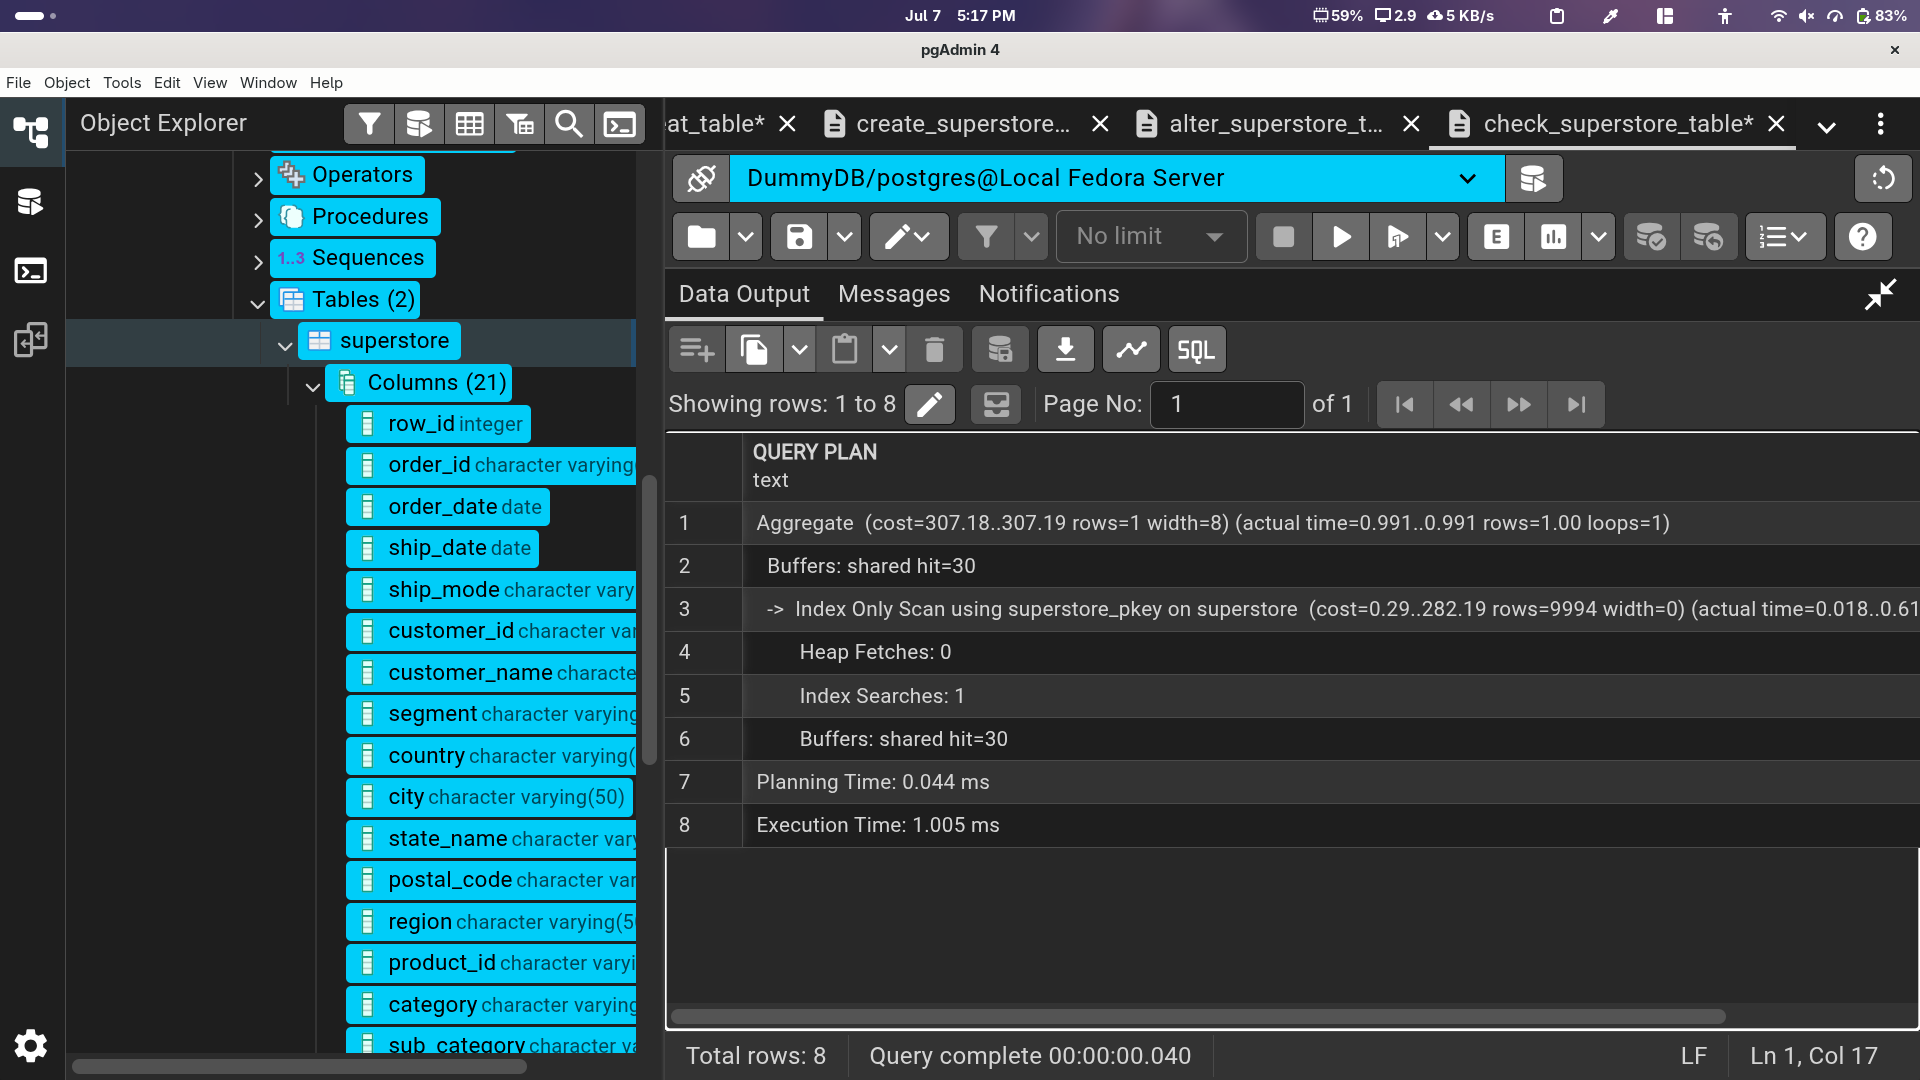

- in the image above, you can see that there were zero heap fetches and line number 3 confirms "index only scan" and you can see there were 30 hits (so the total pages read were 30 to accumulate the count(*))

---

## Part 6: Deliverables

### Theory

- all of it is present in this notebook or in readme.md


### Screenshots

- embedded in the notebook and in the screenshots directory too

### SQL Files

- view the SQL-Files directory

---